# Introducing statistical models

## What are mathematical and statistical models?
Before talking about quantum information, I want to talk about what a mathematical model is. The goal of a mathematical model is to use math to predict something in life. It could be the motion of planets, or of hurricanes, or maybe of stock prices. Although the math is not particularly difficult, quantum physics is very abstract and has a lot of moving parts and because of this, I think it's worth working through some more intuitive examples. We start by describing some simple statistical models (mathematical models where there's a level of randomness).

## Example: modelling a coin flip
Suppose that we want to make a mathematical model for predicting the odds that you get heads vs tails in a coin flip. In hypothetical situations, coins are usually assumed to be fair (equal odds of giving you heads or tails) but in general it may not be (we would have to generate data in order to find out what the odds are for the coin).
- First we make a model for the probability of the possible scenarios of the system from previous observations and logical reasoning. For a coin, the two scenarios are $Heads$ or $Tails$ and the previous observations might be collected by fliping a coin a bunch to see which land on tails and which on heads.
- We can make a predictor that uses the probabilities to make a prediction.
- We decide on a way of comparing our predictor vs new observed phenomena to see how good our model performed.

Let's give a python program where it predicts the odds a coin flip will come out heads vs tails. So, the input is data from coin flips, and the predictor will tell you the ratio
$$
    \frac{P(Heads)}{P(Tails)} \;.
$$

For example, suppose we ran 100 flips and got the following output:

In [39]:
import numpy as np

n_flips = 1000
def heads_or_tails(n):
    if n == 1:
        return 'heads'
    else:
        return 'tails'

def coin_flip_generator(n_flips, p=0.75):
    sample = np.random.binomial(n=1, p=p, size=n_flips)
    return [heads_or_tails(n) for n in sample]

sample = coin_flip_generator(n_flips=n_flips, p=0.75)
num_heads = sample.count('heads')
num_tails = sample.count('tails')
print(f'sample data: {sample}')
print(f'Number of heads: {num_heads}')
print(f'Number of tails: {num_tails}')

sample data: ['heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'tails', 'heads', 'tails', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'tails', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'tails', 'head

How can we leverage this information to make a model?

First, we need to make a model of $P(Heads)$ and $P(tails)$. One reasonable thing we could do is take
$$
    P(Heads) = \frac{\text{Number of heads in our sample}}{\text{Number of flips in the sample}}
$$
and take $P(Tails) = 1-P(Heads)$.

From the probabilities, our predictor is then:
$$
    Predictor = \frac{P(Heads)}{P(Tails)}\;.
$$
Let's use python to calculate out the predictor from the sample data above.

In [40]:
P_heads = num_heads/n_flips
P_tails = num_tails/n_flips
Predictor = P_heads/P_tails
print(f'predictor odds of heads vs tails : {Predictor}')

predictor odds of heads vs tails : 2.8167938931297707




This is a reasonable hypothesis, but there should be some way to test whether this produces a better model by comparing with real data. Let's make a list of 100 data points to test our model on.

In [41]:
n_flips = 100

test_data = coin_flip_generator(n_flips=n_flips, p=0.75)
print(f'test data: {test_data}')

test data: ['heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads']


How can we use the test data to check if our model is good? One test could be to compare the odds that we got from our predictor vs the odds coming from our test data.

In [42]:
print(f'predictor odds: {Predictor}')
print(f'test data odds: {test_data.count('heads')/test_data.count('tails')}')
print()

predictor odds: 2.8167938931297707
test data odds: 4.2631578947368425



This is the skeleton of any statistical predictor: first we determine probability of each output occurring, and then use the probabilities to make a concrete prediction. Finally, we compare the predictor to real life data.

## Example: Fisher's Iris data set.

A classic example of a statistical predictor comes from Fisher's Iris dataset. This gives us a bunch of example of Iris flowers and asks us to predict which flower we have given various physical properties of the flower. We look at some of the data below:

In [43]:
import pandas as pd
from sklearn.datasets import load_iris

iris_data = load_iris(return_X_y=False, as_frame=True)
target_names = iris_data.target_names
iris_data = pd.DataFrame(data= np.c_[iris_data['data'], iris_data['target']],
                     columns= iris_data['feature_names'] + ['target'])
iris_data['target'] = iris_data['target'].apply(lambda x: target_names[int(x)])
display(iris_data)
print(f'species names: {target_names}')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


species names: ['setosa' 'versicolor' 'virginica']


I can't go collect Iris data easily, so I'm going to split our data set into a chunk that we'll use to analyze and make a predictor, and a test set that we'll use to see how well our predictor does on real data. I make the arbitrary choice of taking 1/3 of the data as our test set.

In [44]:
from sklearn.model_selection import train_test_split
iris_data_train, iris_data_test = train_test_split(iris_data,test_size=0.333, stratify=iris_data['target'])

Our goal is the same as before. If we are given the sepal and petal length and width, can we give a probability that the iris is setosa, versicolor, or virginica? We can visualize some of the data to see if we recognize any patterns.

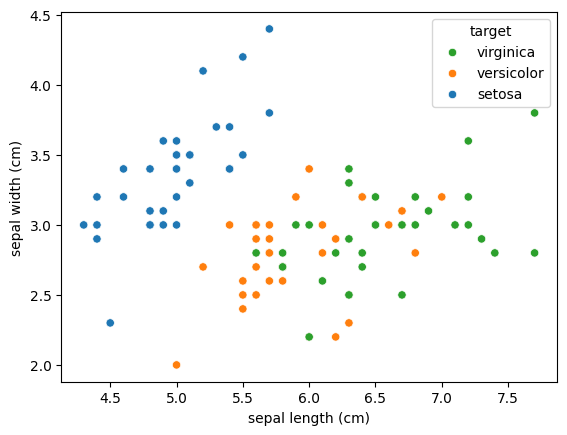

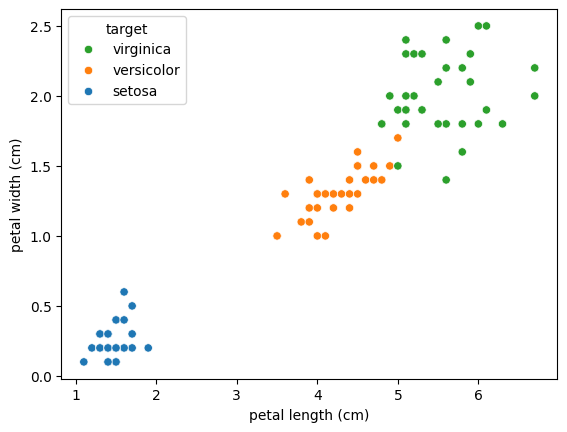

In [45]:
import seaborn as sns
from matplotlib import pyplot as plt
palette = {
    'virginica': 'tab:green', 'setosa': 'tab:blue', 'versicolor': 'tab:orange'
}
sns.scatterplot(data=iris_data_train, x='sepal length (cm)', y='sepal width (cm)', hue='target', palette=palette);
plt.show()
sns.scatterplot(data=iris_data_train, x='petal length (cm)', y='petal width (cm)', hue='target', palette=palette);
plt.show()

It looks like the petal dimensions are a strong predictor for the iris data. So, we can ask: if someone gave me a petal width and petal length, how can I assign a probability that it's in one of the three classes? We'll do this by assigning a bell curve for each variety of iris: we'll put a peak of the bell curve around the middle of each blob, and have it decay depending on how spread out the data is. In the graph below, we only show a 'slice' of the bell curve along the most important axis.

In [46]:
# Doing some math to calculate out the dimensions of the bell curve.
species = iris_data['target'].to_list()
data_species = dict()
for t in species:
    data_species[t] = iris_data_train[iris_data_train['target'] == t][['petal length (cm)', 'petal width (cm)', 'target']]

mean = dict()
cov = dict()
x = dict()
y = dict()
for t in species:
    mean[t] = data_species[t][['petal length (cm)', 'petal width (cm)']].mean()
    cov[t] = data_species[t][['petal length (cm)', 'petal width (cm)']].cov()

In [47]:
from scipy.stats import multivariate_normal

def get_bell_curve(t, x,y):
    rv = multivariate_normal(mean=mean[t], cov=cov[t])

    return rv.pdf((x,y))

plot = dict()
combined_plot = dict()
for t in species:

    x_vals = np.linspace(1,8, 1000)
    y_vals = np.linspace(0,3, 1000)

    data_species[t]['z'] = [0 for _ in range(len(data_species[t]))]

    plot[t] = pd.DataFrame({
        'petal length (cm)':x_vals,
        'petal width (cm)':y_vals,
        'z':[get_bell_curve(t,x,y) for (x,y) in zip(x_vals, y_vals)]
    })

    combined_plot[t] = pd.concat([plot[t],data_species[t]])

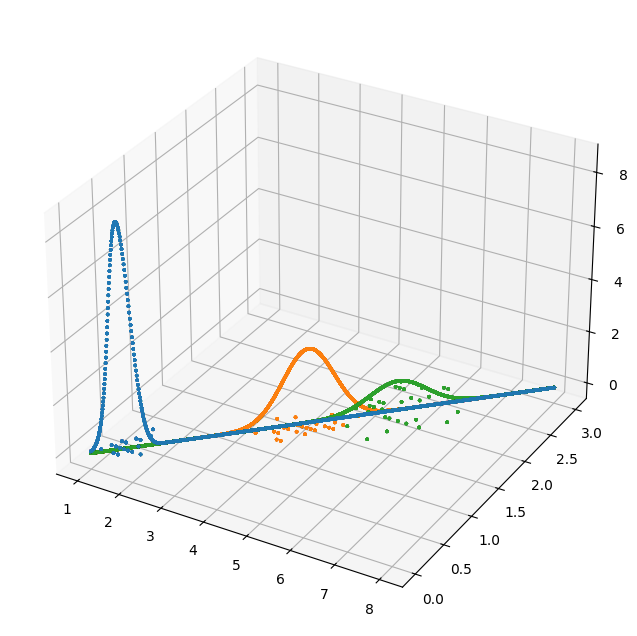

In [48]:
# Customizing the scatter plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

colors =dict()
colors['setosa'] = 'tab:blue'
colors['versicolor'] = 'tab:orange'
colors['virginica'] = 'tab:green'


for t in species:
    ax.scatter(combined_plot[t]['petal length (cm)'],
               combined_plot[t]['petal width (cm)'],
               combined_plot[t]['z'],
               c=colors[t],
               s=2,
               alpha=0.3)

The area under bell curve is proportional to the probability that a given point in that region is of one species. Our predictor then is simple: given the dimensions of a petal, pick the species that corresponds to the largest value in the bell curve.

In [49]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

def integerize(str):
    if str == 'setosa':
        return 0
    elif str == 'versicolor':
        return 1
    else:
        return 2

qda = QuadraticDiscriminantAnalysis()
X_train = iris_data_train[['petal length (cm)', 'petal width (cm)']].values
y_train = iris_data_train['target'].apply(integerize).values

X_test = iris_data_test[['petal length (cm)', 'petal width (cm)']].values
y_test = iris_data_test['target'].apply(integerize).values

qda.fit(X_train, y_train)

petal_length = iris_data['petal length (cm)']
petal_width = iris_data['petal width (cm)']

feature_1, feature_2 = np.meshgrid(
    np.linspace(petal_length.min()-1, petal_length.max()+1),
    np.linspace(petal_width.min()-1, petal_width.max()+1)
)

grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
y_pred = np.reshape(qda.predict(grid), feature_1.shape)

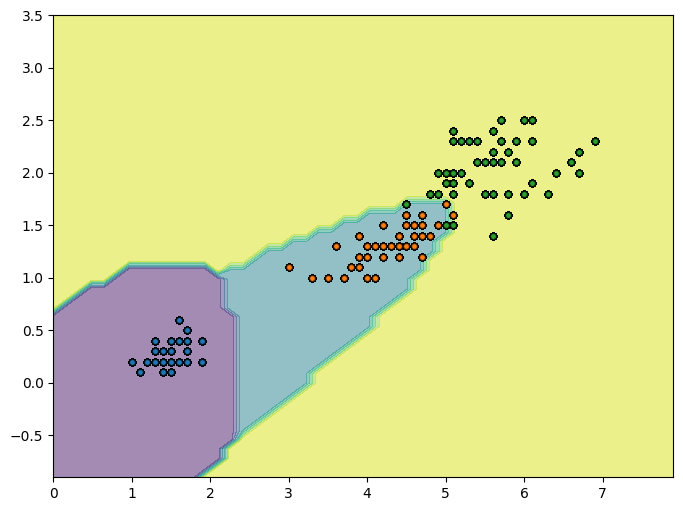

In [50]:
plt.figure(figsize=(8, 6))
plt.contourf(feature_1, feature_2, y_pred, alpha=0.5)

for t in species:
    plt.scatter(iris_data[iris_data['target']==t]['petal length (cm)'],
                        iris_data[iris_data['target']==t]['petal width (cm)'],
                        c=colors[t],
                        s=20,
                        alpha=0.5,
                        edgecolor='black')

plt.show()

We see that *most* of the data is classified properly, with a few outliers.

**Question**: What possible issues do you see in this model?

Finally, we can give a quantitative measure of how well our model does on the test data that we saved (and did not use to make our model). Here we just look at the accuracy of the model: the average number of correct predictions that our model makes.

In [51]:
qda.score(X_test, y_test)

0.96

That's pretty good!

Let's look at another model with more strict assumptions: we impose that the bell curve has equal spread for each of the species of iris. It turns out that this implies that the decision boundary has to be a line. Which model do you think would perform better in which scenarios? Deciding on when will work and when the model will not work is an important part of designing any model.

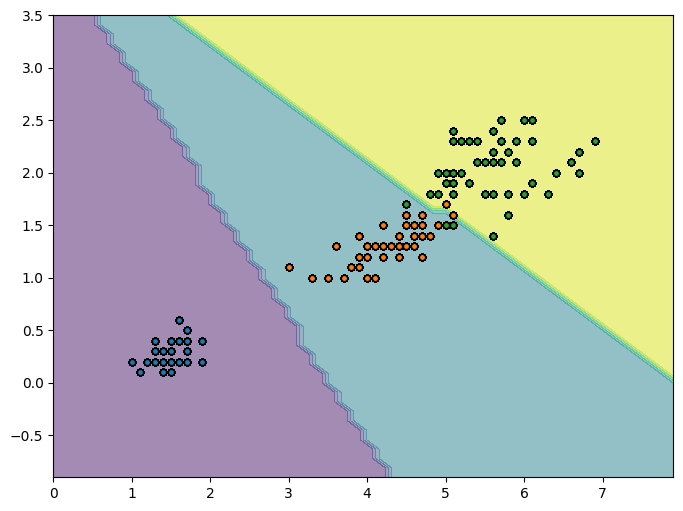

In [52]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def integerize(str):
    if str == 'setosa':
        return 0
    elif str == 'versicolor':
        return 1
    else:
        return 2

lda = LinearDiscriminantAnalysis()
X_train = iris_data_train[['petal length (cm)', 'petal width (cm)']].values
y_train = iris_data_train['target'].apply(integerize)
lda.fit(X_train, y_train)

petal_length = iris_data['petal length (cm)']
petal_width = iris_data['petal width (cm)']

feature_1, feature_2 = np.meshgrid(
    np.linspace(petal_length.min()-1, petal_length.max()+1),
    np.linspace(petal_width.min()-1, petal_width.max()+1)
)

grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
y_pred = np.reshape(lda.predict(grid), feature_1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(feature_1, feature_2, y_pred, alpha=0.5)

for t in species:
    plt.scatter(iris_data[iris_data['target']==t]['petal length (cm)'],
                        iris_data[iris_data['target']==t]['petal width (cm)'],
                        c=colors[t],
                        s=20,
                        edgecolor='black')

In [53]:
lda.score(X_test, y_test)

0.94

## Example: double slit experiment with table tennis balls
Our next model has the following setup: suppose that we fire a bunch of table tennis balls, one at a time, at random at a wall with two slits in it. Behind the slits in some distance away are a series of equally spaced pressure plates. When a ball hits a plate, a signal is sent to a machine that counts how many balls hit each plate. A diagram is shown below:

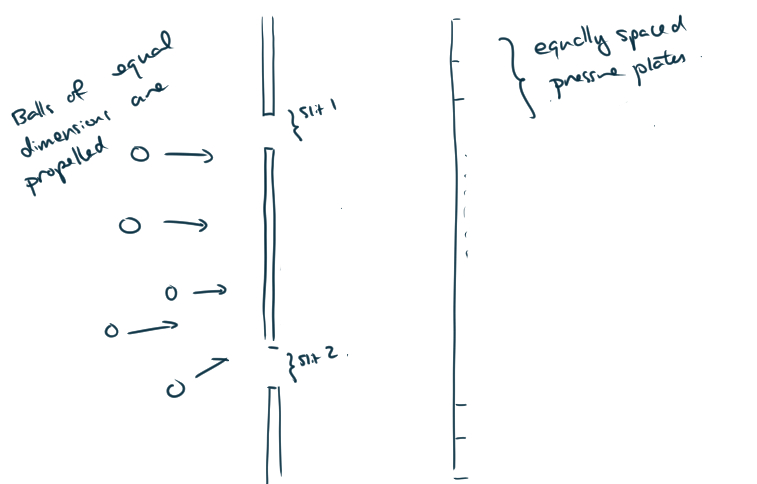

In [54]:
from IPython.display import Image
Image('data/double_slit_1.jpg')

Our goal is to give a predictor that takes as input the position of the slits, the distance to the wall, and how many balls were thrown and gives as output the distribution of balls detected by the pressure plates. Let's say there are 1000 pressure plates so that we can see the spread of the balls more accurately. We can imagine that the computer on the other end stores the number of pressure plates as a list:
$$
    [0,0,\ldots, 0]
$$
where the first index represents the top plate, and the last index represents the bottom plate. For example, if pressure plate at index $0$ gets a signal and at index $1$ gets three signals, the list becomes
$$
    [1,3,0,\ldots, 0]
$$
and so on. Notice that if we can model the probability that, given one ball is thrown, it hits the plate at index $k$, then we can just multiply this probability by the number of balls thrown to get a good estimate at how many balls hit index $k$. Therefore, a model of this system amounts to determining the probability that a ball hits each plate.


Some basic probability theory tells us that the probability that one ball hits pressure plate at index $k$ is given by
$$
\begin{align*}
    Prob(\text{ball hits plate k}) &= Prob(\text{ball hits plate k}|\text{ball goes through slit 1})\cdot Prob(\text{ball goes through slit 1}) \\
    &+ Prob(\text{ball hits plate k}|\text{ball goes through slit 2})\cdot Prob(\text{ball goes through slit 2}) \\
    &+ Prob(\text{ball hits plate k}|\text{ball goes through neither slits})\cdot Prob(\text{ball goes through neither slits})
\end{align*}
$$
Here the notation $Prob(X|Y)$ means: given that $Y$ occurred, what is the probability that $X$ will occur? For example, if the ball goes through slit $1$, then the ball is very likely to hit a plate near the top, and very unlikely to hit a plate near the bottom.

We know that if a ball goes through neither slits, then it can never hit a plate. So,
$$
    Prob(\text{ball hits plate k}|\text{ball goes through neither slits}) = 0\;.
$$
Therefore, our equation reduces to
$$
\begin{align*}
    Prob(\text{ball hits plate k}) &= Prob(\text{ball hits plate k}|\text{ball goes through slit 1})\cdot Prob(\text{ball goes through slit 1}) \\
    &+ Prob(\text{ball hits plate k}|\text{ball goes through slit 2})\cdot Prob(\text{ball goes through slit 2}) \;.
\end{align*}
$$
Beyond this, unless we are given additional information about the setup, we will have to do some data collection to give a good model for how the remaining probabilities work. Let's run a simulation with the following setup:
- The distance of each slit from the top/bottom of the system is 1/5 meters.
- The wall of detectors is 1 meter tall
- The gap between the first and second wall is 1/5 meters

We know that in order to collect data for this model, we will want to put detectors by each slit to detect whether the ball went through slit $1$, slit $2$, or neither slits.

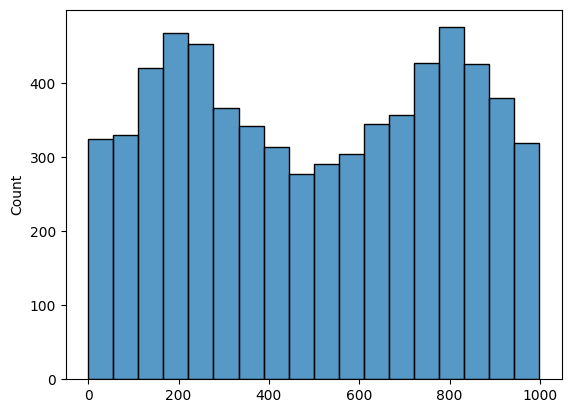

In [55]:
# Here is a simulation of the data.
sample_size = 100000
num_bins = 1000
# The balls have equal chance of going through each slit, with a 90% chance of missing both slits.
sample_slit = np.random.multinomial(n=1, pvals=[0.9, 0.05, 0.05], size=sample_size)

# We model which the angle that a ball going through a slit uniformly randomly and use that + trigonometry to
# determine the plate that a ball hits.
sample_angle = dict()
for k in range(1,3):
    sample_angle[k] = np.random.uniform(-np.pi/2, np.pi/2, size=sample_size)

def plate_location(slit: int, angle: float) -> int:
    if slit == 1:
        pos=1/5+np.tan(angle)/5
    elif slit == 2:
        pos=(1-1/5)+np.tan(angle)/5
    else:
        pos = -1

    if pos > 1 or pos < 0:
        return -1
    else:
        return np.floor(pos*num_bins)

sample_loc = dict()
for k in range(1,3):
    sample_loc[k] = [plate_location(k, theta) for theta in sample_angle[k]]

dist = []
for sample in range(sample_size):
    which_slit = sample_slit[sample]
    if which_slit[0] == 1:
        dist.append(-1)
    elif which_slit[1] == 1:
        dist.append(sample_loc[1][sample])
    else:
        dist.append(sample_loc[2][sample])

dist = [x for x in dist if x != -1]
sns.histplot(dist);

Notice that there are two peaks roughly corresponding to the location of the slits. The histogram is cut off on the edges because the plates only have a finite size. We can also look at the proportion of balls that went through slit 1 or slit 2. It looks like there was a roughly even chance that a ball went through either slit.

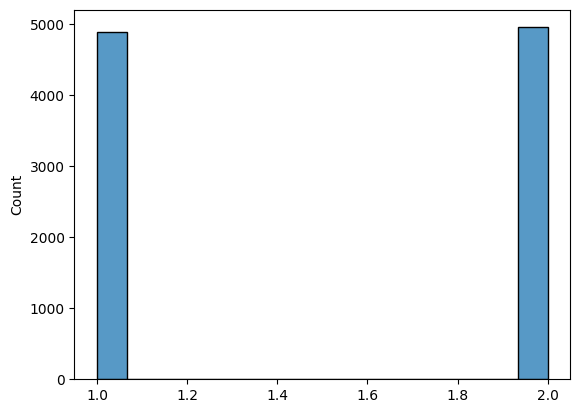

In [56]:
def which_slit(data_point: list) -> int:
    if data_point[0] == 1:
        return 0
    elif data_point[1] == 1:
        return 1
    else:
        return 2

sns.histplot([which_slit(sample) for sample in sample_slit if sample[0] != 1]);

Notice that going through either slit is roughly equal, and we can hypothesize that
$$
    Prob(\text{ball goes through slit }k) = \frac{\text{size of slit k}}{\text{size of wall}}
$$
for subsequent calculations.

Finally, we can look at the number of hits for each slit individually.

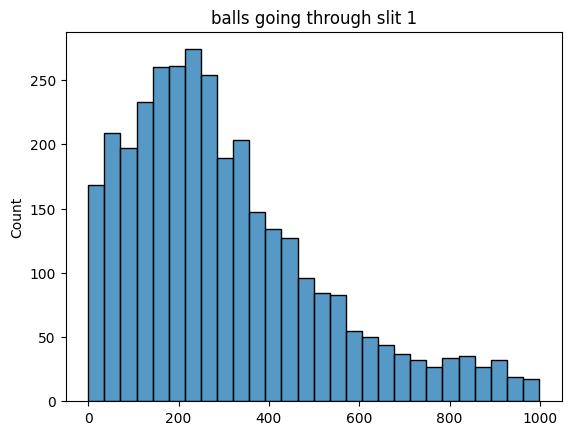

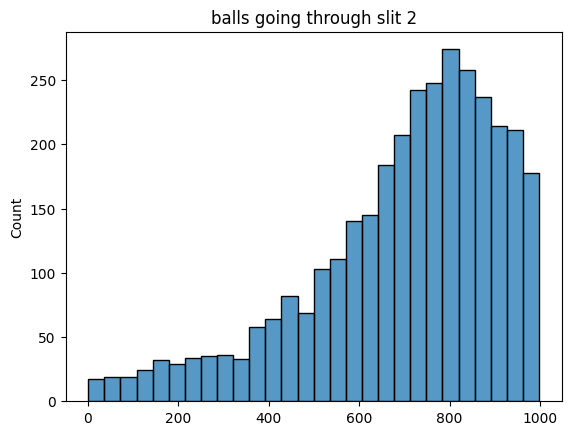

In [57]:
dist_sep = dict()
for k in range(1,3):
    dist_sep[k] = []
    for sample in range(sample_size):
        which_slit = sample_slit[sample]
        if which_slit[k] == 1:
            dist_sep[k].append(sample_loc[k][sample])
        else:
            dist_sep[k].append(-1)

    dist_sep[k] = [x for x in dist_sep[k] if x != -1]
    sns.histplot(dist_sep[k])
    plt.title(f'balls going through slit {k}')
    plt.show()

Unsurprsingly, the peaks are formed at the location of the slits. We can do two models
- one where we treat the data we have collected as *the* distribution for subsequent examples for this experimental setup (no assumptions but will not generalize well to other setups)
- use some probability theory and some assumptions to figure out these distributions.

For this experimental setup, since the balls are shot totally at random, it makes sense to assume that the angle that a ball going through a slit is shot at is totally random as well. The minimum and maximum angle that the ball can achieve is related to the size of the ball (you can't achieve a ball going at near parallel to the wall), but we will just assume the balls are small enough where this does not matter.

By trigonometry, if a ball shoots at an angle $\theta$ ($\theta = 0$ means that it's shooting perpendicular to the wall) the position that a ball lands in is then given by the formula
$$
    \tan(\theta)\cdot \text{distance between the walls} + \text{distance from the top of system to the center of the slit}
$$
and the probability distribution associated to this formula is called the Cauchy distribution: if the distance from the top of the system to slit $k$ is equal to $d_k$ and $\alpha$ is the distance between the walls, then
$$
    Prob(\text{ball hits position}x |\text{ball goes through slit 1}) = \frac{1}{\pi\cdot\alpha}\frac{1}{1+\left(\frac{x-d_1}{\alpha}\right)^2} \;.
$$

Therefore, our hypothetical distribution of balls is given by
$$
    Prob(\text{ball hits position }x) = \frac{\text{length of slit}}{2 \cdot \text{length of wall}}\cdot \left(\frac{1}{\alpha}\frac{1}{1+\left(\frac{x-d_1}{\alpha}\right)^2} + \frac{1}{\alpha}\frac{1}{1+\left(\frac{x-d_2}{\alpha}\right)^2}\right)
$$
and a plot of this distribution compared to our data looks like this:

<Axes: >

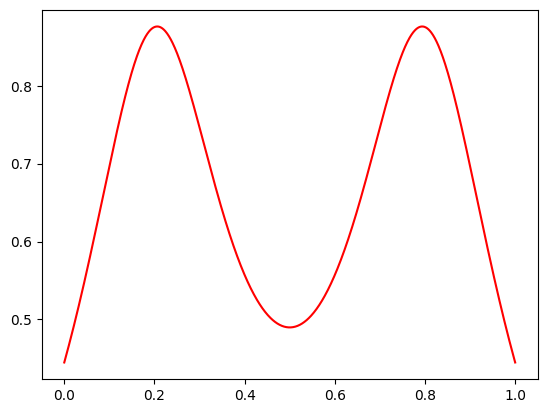

In [58]:
from scipy.integrate import quad #to renormalize the distribution
def prob_position(x: float, alpha:float, d1:float, d2:float) -> float:
    p_slit = 0.05

    def cauchy_dist(x: float, d: float, alpha: float) -> float:
        return ((1+ (x-d)**2/alpha**2)*np.pi*alpha)**(-1)


    return 0.5*(cauchy_dist(x, d1, alpha) + cauchy_dist(x, d2, alpha))

def normalized_data(lst: list) -> float:
    return [x/1000 for x in lst]

x_vals = np.linspace(0,1,1000)
y_vals = prob_position(x_vals, 1/5, 1/5, 4/5)

sns.lineplot(x=x_vals, y=y_vals, color='red')

We can see how a plot of this probability distribution compares to our data plot. Note that this plot is rescaled so that the area under both the data and the curve are each equal to $1$ (so that these correspond to probabilities).

<Axes: ylabel='Density'>

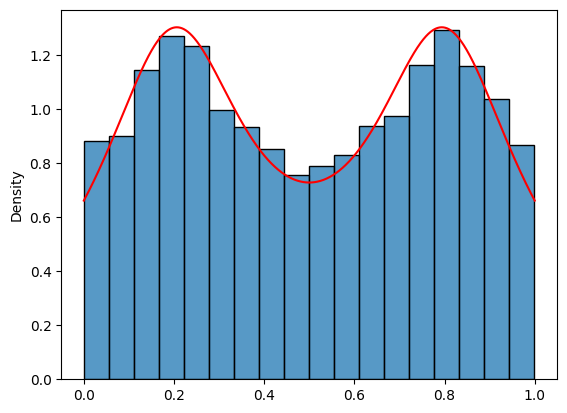

In [59]:
x_vals = np.linspace(0,1,1000)

normalization_term = quad(prob_position, 0,1, args = (1/5,1/5,4/5))[0]

y_vals = prob_position(x_vals, 1/5, 1/5, 4/5)*(normalization_term)**(-1)

normalized_list = normalized_data(dist)

sns.histplot(normalized_list, stat='density')
sns.lineplot(x=x_vals, y=y_vals, color='red')

That's pretty close! We can use our model to give the probability that a ball hits detector $k$ by measuring the area under the red curve for that region.

How can we test how well our model performs against new setups? One reasonable way to measure this is by using something called *Kullback–Leibler divergence*. To describe KL-divergence, let's go through an example.

### An aside about Kullback–Leibler divergence

Suppose that you have a pile of heavily weighted coins: the probability of getting heads is 0.999. Say you grabbed one of the coins in the pile. If you flipped the coin and got tails, you should be pretty impressed! Suppose that you flipped the coin a few times and got these results:

In [60]:
observed_data = [heads_or_tails(x) for x in np.random.binomial(1,0.5,100)]
print(observed_data)
for event in ['heads', 'tails']:
    print(f'number of {event}: {len([x for x in observed_data if x == event])}')

['tails', 'tails', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'tails', 'tails', 'tails', 'tails', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'tails', 'tails', 'tails', 'tails', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'tails', 'heads', 'tails', 'tails', 'tails', 'tails', 'heads', 'tails', 'tails', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'tails', 'heads', 'tails', 'heads', 'heads', 'tails', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'tails', 'tails', 'tails', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'heads', 'tails', 'heads', 'heads', 'tails', 'heads', 'tails', 'tails', 'heads', 'heads', 'tails', 'tails', 'heads', 'heads', 'tails', 'heads', 'tails', 'tails', 'heads', 'tails', 'heads', 'heads']
number of heads: 56
number of tails: 44


Now you should be pretty suspicious. The likelihood of getting so many tails from such a weighted coin should be considered a remarkable event!

We can measure the amount of *surprise* that you get an event $x$ by calculating the negative logarithm of the probability of the event. The graph of $-\log(p(x))$ looks like this:

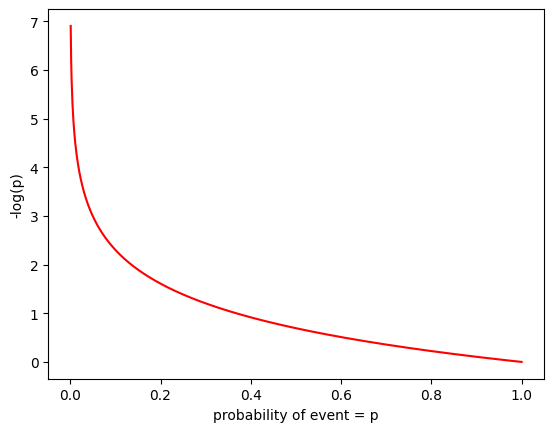

In [61]:
x_vals = np.linspace(0.001,1,1000)
sns.lineplot(x=x_vals, y=-np.log(x_vals), color='red')
plt.xlabel('probability of event = p')
plt.ylabel('-log(p)')
plt.show()

As the probability gets close to $0$, the amount of surprise goes to infinity. Meanwhile, if the probability of the event $x$ is $1$, then the amount of surprise should be $0$.

The Kullback–Leibler divergence is the average amount of surprise that you detect from new observations, given your assumptions about the distribution of the events. A formula for this is given by
$$
    D_{KL}(q|p) = \sum_{x \text{ is an event}} -\log\left(\frac{p(x)}{q(x)}\right) \cdot q(x)
$$
where $q(x)$ is the proportion of observed data that gave event $x$. If we compute $q(x)$ for the data that we have above, then we get
$$
\begin{align*}
    q(Heads) &= \frac{\text{number of heads in data}}{\text{number of flips}} \text{ and } \\
     q(Tails) &= \frac{\text{number of tails in data}}{\text{number of flips}} \;.
\end{align*}
$$
The KL divergence is
$$
    D_{KL}(q|p) = -\log\left(\frac{0.999}{q(Heads)}\right)\cdot q(Heads) -\log\left(\frac{0.001}{q(Tails)}\right)\cdot q(Tails) \;.
$$

In [62]:
# Compute the KL divergence
q = dict()
for event in ['heads', 'tails']:
    q[event] = len([x for x in observed_data if x == event])/len(observed_data)

H = -np.log(0.999/q['heads'])*q['heads'] - np.log(0.001/q['tails'])*q['tails']
print(H)

2.3540428026865743


Meanwhile, if we instead measure the KL divergence assuming that the coin is fair, we get

In [63]:
print(-np.log(0.5/q['heads'])*q['heads'] - np.log(0.5/q['tails'])*q['tails'])

0.007217380307572421


A much more reasonable score!

We use KL divergence to compare newly observed data to our model.

### KL-divergence for new data

Let's construct a new setup. Say $l_1 = 1/3$, $l_2 = 6/7$, and $\alpha = 1/4$. Our model distribution looks like:

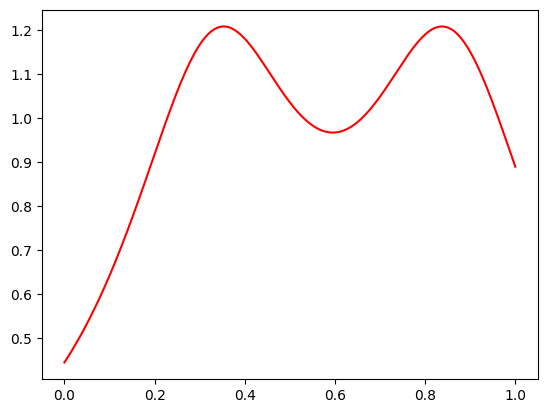

In [64]:
x_vals = np.linspace(0,1,1000)
normalization_term = quad(prob_position, 0,1, args = (1/4,1/3,6/7))[0]
y_vals = prob_position(x_vals, alpha=1/4, d1=1/3, d2=6/7)*(normalization_term)**(-1)

sns.lineplot(x=x_vals, y=y_vals, color='red');

As well, we simulate some data with these parameters and plot it against our model.

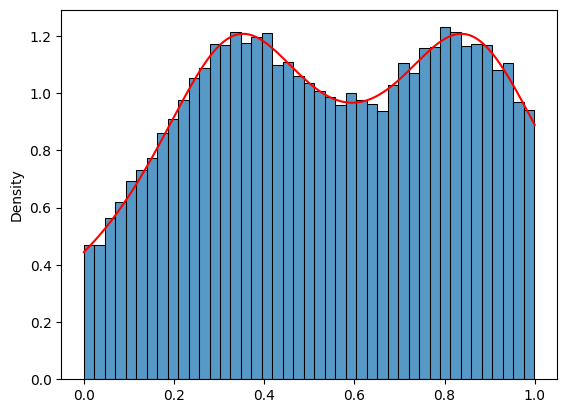

In [65]:
# Here is a simulation of the data.
sample_size = 1000000
num_bins = 1000
ALPHA = 1/4
D1 = 1/3
D2= 6/7
# The balls have equal chance of going through each slit, with a 90% chance of missing both slits.
sample_slit = np.random.multinomial(n=1, pvals=[0.9, 0.05, 0.05], size=sample_size)

# We model which the angle that a ball going through a slit uniformly randomly and use that + trigonometry to
# determine the plate that a ball hits.
sample_angle = dict()
for k in range(1,3):
    sample_angle[k] = np.random.uniform(-np.pi/2, np.pi/2, size=sample_size)

def plate_location(slit: int, angle: float, alpha:float, d1:float, d2:float) -> int:
    if slit == 1:
        pos=d1+np.tan(angle)*alpha
    elif slit == 2:
        pos=d2+np.tan(angle)*alpha
    else:
        pos = -1

    if pos > 1 or pos < 0:
        return -1
    else:
        return np.floor(pos*num_bins)

sample_loc = dict()
for k in range(1,3):
    sample_loc[k] = [plate_location(k, theta, ALPHA, D1, D2) for theta in sample_angle[k]]

dist = []
for sample in range(sample_size):
    which_slit = sample_slit[sample]
    if which_slit[0] == 1:
        dist.append(-1)
    elif which_slit[1] == 1:
        dist.append(sample_loc[1][sample])
    else:
        dist.append(sample_loc[2][sample])

dist = [x for x in dist if x != -1]
sns.histplot(normalized_data(dist), stat='density');
sns.lineplot(x=x_vals, y=y_vals, color='red');

Now we calculate the KL divergence. Remember in the previous example that a surprising assessment lead to a value of around 3, and a fair assessment lead to a value near 0.

In [66]:
# First we discretize the model data.
def model(x:float, alpha: float, d1: float, d2: float) -> float:
    normalization_term = quad(prob_position, 0,1, args = (alpha,d1,d2))[0]
    return prob_position(x, alpha, d1, d2)*(normalization_term)**(-1)

p = [quad(model,x/1000,(x+1)/1000,args = (ALPHA,D1,D2))[0] for x in range(1000)]
q = [dist.count(x) for x in range(1000)]
n_samples = sum(q)
q = [x/n_samples for x in q]

def KL_divergence(p: list, q:list) -> float:
    H = 0
    for s,t in zip(p,q):
        H += -np.log(s/t)*t
    return H

print(f'The KL divergence is: {KL_divergence(p,q)}')

The KL divergence is: 0.007954158125359557


## Example: Double slit using nanoscopic balls
We saw in the previous model that in order to model the distribution of balls hitting the pressure plates, it was enough to calculate the proportion of balls going through each slit, and compute the distribution of the balls given that they go through one slit or another. Below I give a simulation of the same experiment, but where all of the objects are on the order of nanometers or smaller. For example, we could shoot electrons out by heating a bit of metal. Our pressure plates would be electron detectors. When an electron hits a plate, the change in electric field will give a signal to our machine, which will be recorded as a single source of detection.

Let's look at a scatter plot of how the distribution would look:

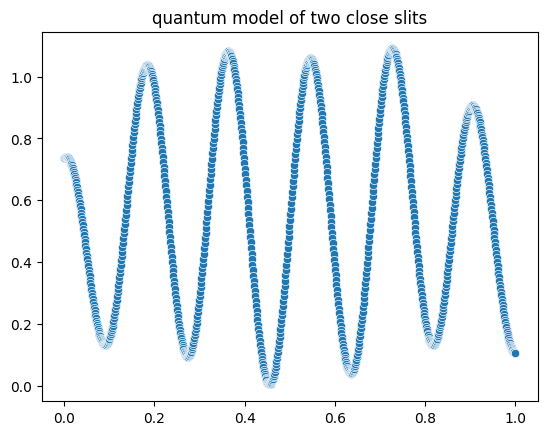

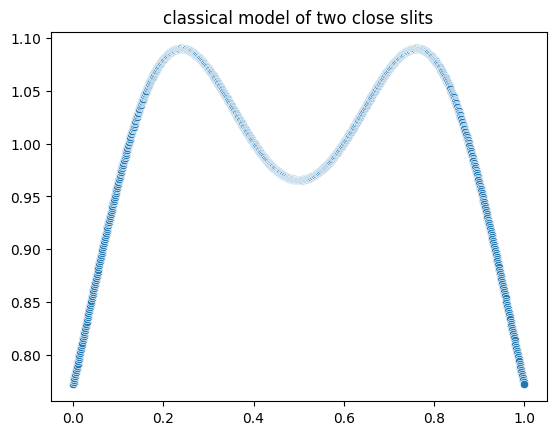

In [67]:
def cauchy_dist(x: float, alpha: float, d: float) -> float:
        return ((1+ (x-d)**2/alpha**2)*np.pi*alpha)**(-1)

def q_model(x:float, alpha: float, d: float, phase: float) -> float:
    return np.sqrt(cauchy_dist(x, alpha, d))*np.exp(1j*x*np.pi*phase)

D1 = 2/10
D2 = 8/10
ALPHA = 1/3

x_vals = np.linspace(0,1,1000)
phi1 = q_model(x_vals,ALPHA,D1, -11)
phi2 = q_model(x_vals,ALPHA,D2, 0)
phi = (phi1+phi2)/np.sqrt(2)
plt.title('quantum model of two close slits')
sns.scatterplot(x=x_vals, y=np.absolute(phi)**2)
plt.show()
plt.title('classical model of two close slits')
c_model = model(x_vals,ALPHA,D1,D2)
sns.scatterplot(x=x_vals, y=c_model)
plt.show()

**Warning** Many people I've talked to seem to get this phenomenon confused with entanglement. Entanglement is a property of a many particle system. Remember that in the double slit experiment, each ball is shot *one at a time*, so this is a *single particle system*.

What if we first looked at which slit the ball goes through? Maybe this will illuminate what weird behaviour this is caused by. The distribution looks like:

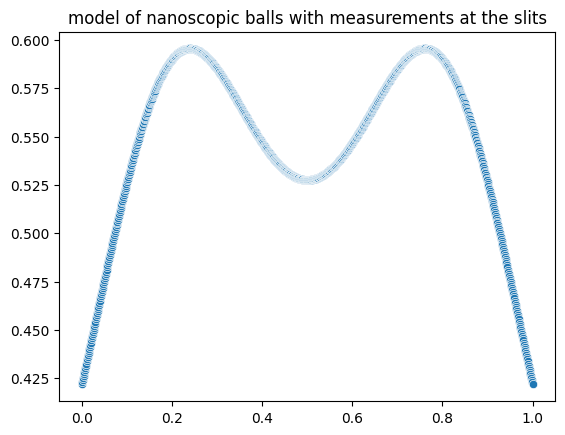

In [68]:
plt.title('model of nanoscopic balls with measurements at the slits')
sns.scatterplot(x=x_vals, y=0.5*(np.absolute(phi1)**2+ np.absolute(phi2)**2))
plt.show()

Something strange is going on: when we measure which ball goes through which slit, we lose the structure that we saw before. This suggests that somewhere along the way we've made an incorrect assumption in the design of our models. In fact the problem was right at the beginning: our ideas about how probabilities behave classically are just wrong on the small scale. 

In the early 20th century, Birkhoff and von Neumann realized that the only way we can properly capture the logical inconsistencies for modelling probabilities of small scale systems is to work with a different model of logic, called quantum logic. In the next lecture, we will build up the math needed to understand quantum logic, as well the basic recipe for how to create a quantum model.